# NRW Residential Building Stock — K-Means Clustering
**Method 3b | Per Building Type | CO2online Stromspiegel 2025**

This notebook clusters Method 3b electricity demand per building type.
Same structure as `clustering_m1_final.ipynb` — run them side by side to compare results.

| Step | What it does |
|------|--------------|
| 1 | Imports and configuration |
| 2 | Load data |
| 3 | Outlier removal |
| 4 | Demand distributions |
| 5 | Helper functions |
| 6 | Cluster per building type |
| 7 | Whole dataset clustering (comparison) |
| 8 | Combination count comparison |
| 9 | Gap analysis |
| 10 | Cluster size validation |
| 11 | Refurbishment state cross-tabulation |
| 12 | Save Excel |

## 1. Imports & Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
# Relative paths — works on any PC as long as all files are in the same folder
BASE_DIR   = os.getcwd()
FILE_M3B   = os.path.join(BASE_DIR, 'DEA_method3b_final.parquet')
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

# Search range for k — algorithm picks best automatically within this range
K_MIN        = 2
K_MAX        = 10
SAMPLE_N     = 30_000   # used only for k-selection speed — full 4M used for final fit
RANDOM_STATE = 42       # fixed seed — same result every run
SIZE_CLASSES = ['SFH', 'TH', 'MFH', 'AB']

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Ready')

Ready


## 2. Load Data

Parquet was built by `pipeline_method3b.ipynb` using the updated CO2online table.
Electricity demand here is calculated differently from Method 1 — see table below.

**Updated CO2online table — WITHOUT electric water heating:**
Values exclude electric DHW because SESMG optimizes domestic hot water separately.
Including it would double-count electricity demand in the simulation.

| Persons | SFH/TH (kWh/yr) | MFH/AB (kWh/yr) | Source |
|---------|:-:|:-:|--------|
| 1 | 1,800 | 1,200 | Statista Mai 2025 |
| 2 | 2,700 | 1,900 | Statista Mai 2025 |
| 3 | 3,500 | 2,400 | Statista Mai 2025 |
| 4 | 4,000 | 2,900 | Statista April 2023 |
| 5 | 4,500 | 3,100 | Statista Mai 2025 |

In [3]:
BASE_DIR   = os.getcwd()
FILE_M3B   = os.path.join(BASE_DIR, 'DEA_method3b_final.parquet')

m3b = pd.read_parquet(FILE_M3B, columns=[
    'id', 'size_class', 'area_m2',
    'elec_m3b_kwh', 'pv_potential_kwh', 'heat_total_kwh',
    'refurbishment_state'
])

print(f'Buildings loaded : {len(m3b):,}')
print(f'\nCount per building type:')
print(m3b['size_class'].value_counts().to_string())
print(f'\nElectricity total : {m3b["elec_m3b_kwh"].sum()/1e9:.2f} TWh/yr')
print(f'BDEW benchmark    : 31.96 TWh/yr')
print(f'Difference        : {(m3b["elec_m3b_kwh"].sum()/1e9 - 31.96)/31.96*100:.1f}%')
m3b.head(3)

Buildings loaded : 4,133,323

Count per building type:
size_class
SFH    2723098
MFH     897247
TH      507633
AB        5345

Electricity total : 22.18 TWh/yr
BDEW benchmark    : 31.96 TWh/yr
Difference        : -30.6%


,id,size_class,area_m2,elec_m3b_kwh,pv_potential_kwh,heat_total_kwh,refurbishment_state
0,DEA_DENW01AL1000CrNT,TH,60.737362,2700,2350.341549,4707.952145,3
1,DEA_DENW01AL10005Mtw,TH,62.125402,2700,2404.054245,7008.479348,2
2,DEA_DENW01AL10005MU2,SFH,84.191153,2700,3257.928217,15706.701539,2


## 3. Outlier Removal — P99.5 per Building Type

OSM data contains industrial buildings misclassified as residential.
They have abnormally large footprints and would distort cluster centres.

**Why P99.5 and not standard deviation:**
Outliers inflate the mean and std themselves — making std-based thresholds too loose to catch them.
P99.5 removes the top 0.5% regardless of the distribution shape.

In [4]:
before = len(m3b)
thresholds = {}

print('P95 thresholds:')
for sc in SIZE_CLASSES:
    mask = m3b['size_class'] == sc
    p95 = m3b.loc[mask, 'area_m2'].quantile(0.95)
    thresholds[sc] = p95
    print(f'  {sc}: {p95:,.1f} m2')

# Vectorised — much faster than row-by-row on 4M rows
keep = pd.Series(True, index=m3b.index)
for sc, thr in thresholds.items():
    keep &= ~((m3b['size_class'] == sc) & (m3b['area_m2'] > thr))
m3b = m3b[keep].copy()

removed = before - len(m3b)
print(f'\nRemoved : {removed:,} ({removed/before*100:.2f}%)')
print(f'Retained: {len(m3b):,}')

P95 thresholds:
  SFH: 216.8 m2
  TH: 140.8 m2
  MFH: 364.7 m2
  AB: 939.9 m2

Removed : 206,668 (5.00%)
Retained: 3,926,655


In [5]:
# Drop buildings with missing heat (should be 0 after pipeline fix)
n_before = len(m3b)
m3b = m3b.dropna(subset=['heat_total_kwh']).copy()
dropped = n_before - len(m3b)
print(f'Missing heat: {dropped:,} buildings dropped' if dropped else 'No missing heat data')

No missing heat data


## 4. Demand Distributions

Shows the spread of demand values across 4M buildings.

**Key difference from Method 1:**
The electricity distribution for Method 3b is more compressed and discrete.
Most SFH and TH buildings have 1 dwelling and 2 persons → all get exactly 2,700 kWh.
This is an artefact of the CO2online lookup table assigning fixed values per dwelling count.

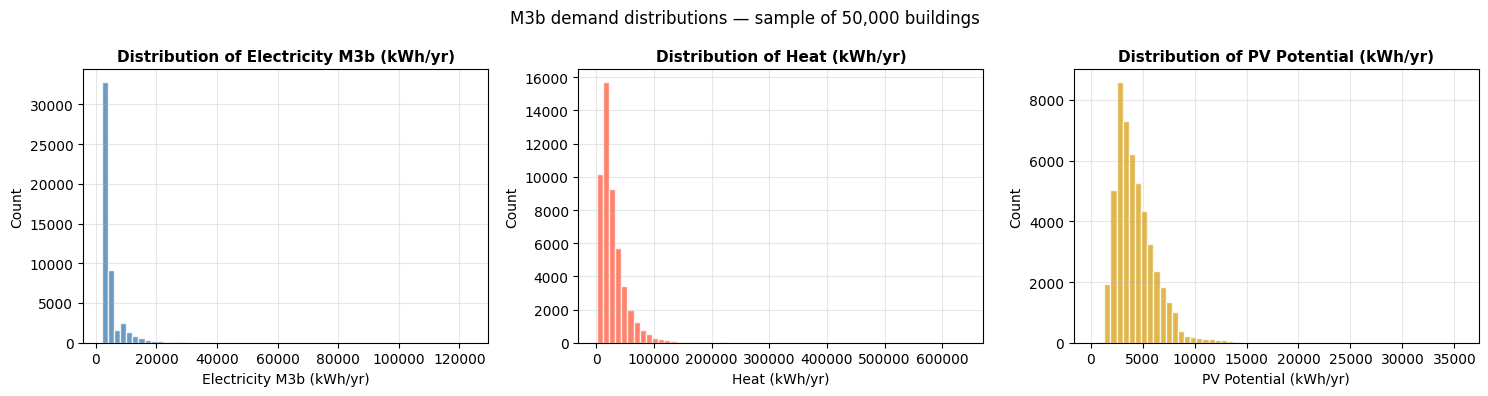

Note: Electricity is compressed vs Method 1 — discrete CO2online lookup table effect


In [6]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['elec_m3b_kwh', 'heat_total_kwh', 'pv_potential_kwh'],
    ['Electricity M3b (kWh/yr)', 'Heat (kWh/yr)', 'PV Potential (kWh/yr)'],
    ['steelblue', 'tomato', 'goldenrod']
):
    sample = m3b[col].sample(50_000, random_state=42)  # 50k sample — shape identical to full 4M
    ax.hist(sample, bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Distribution of {label}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('M3b demand distributions — sample of 50,000 buildings', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'demand_distributions_m3b.pdf'), bbox_inches='tight')
plt.show()
print('Note: Electricity is compressed vs Method 1 — discrete CO2online lookup table effect')

## 5. Helper Functions

### 5.1 Elbow Detection

**What is inertia?**
For every building, calculate the squared distance to its cluster centre. Sum all of these = inertia.
Lower inertia = tighter clusters. Always decreases as k increases — never stops.

**The elbow is where it stops improving meaningfully.**
Draw a line from k=2 to k=10. For each k, measure the perpendicular distance from that point to the line.
The k with the maximum distance = sharpest bend = elbow = selected k.

**Why not silhouette?**
Silhouette always returned k=2 for Method 1 — too coarse for simulation.
For Method 3b electricity, silhouette rises artificially toward 1.0 — an artefact of the
discrete CO2online lookup values creating perfectly separated groups, not genuine cluster quality.
Elbow gave physically meaningful k values in both cases.

In [7]:
def find_elbow(inertias, k_range):
    """
    Finds the k where inertia stops improving meaningfully.
    Uses perpendicular distance from each point to the line connecting k=2 and k=10.
    """
    x1, y1 = k_range[0],  inertias[0]
    x2, y2 = k_range[-1], inertias[-1]
    dx, dy   = x2 - x1, y2 - y1
    line_len = np.sqrt(dx**2 + dy**2)
    distances = [
        abs(dy*k - dx*inertia + x2*y1 - y2*x1) / line_len
        for k, inertia in zip(k_range, inertias)
    ]
    return k_range[np.argmax(distances)]

print('find_elbow() ready')

find_elbow() ready


### 5.2 Main Clustering Function

Nine steps per variable per building type:
1. Clip at P99.9 — protects scaling from extreme demand values without removing buildings
2. StandardScaler — puts all values on same scale so no variable dominates by unit size
3. Sample 30,000 for k-selection — representative enough, runs in seconds
4. Test k = 2 to 10 — record inertia and silhouette at each k
5. Select k via elbow
6. Fit MiniBatchKMeans on ALL buildings — processes in batches of 5,000 for speed
7. Relabel clusters: cluster 0 = lowest demand, cluster k-1 = highest
8. Calculate stats per cluster
9. Save elbow plot and boxplot as PDF

> **Note on the 30,000 sample:** The sample is used only to select the optimal k via the elbow method.
> Once k is selected, the final model is fit on **all buildings** so every building gets a cluster assignment.
> The 30,000 is never the final result.

In [8]:
def cluster_variable(values, label, unit, size_class, output_dir):
    n = len(values)
    if n < K_MIN * 10:
        print(f'  Skipping {label} for {size_class} — too few buildings ({n})')
        return np.zeros(n, dtype=int), pd.DataFrame(), 1

    # Step 1+2: clip extreme values then scale to zero mean unit variance
    cap  = np.percentile(values, 99.9)
    vals = np.clip(values, 0, cap)
    X_all = StandardScaler().fit_transform(vals.reshape(-1, 1))

    # Step 3: sample for k-selection — 30k is enough to represent 4M
    np.random.seed(RANDOM_STATE)
    idx      = np.random.choice(n, min(SAMPLE_N, n), replace=False)
    X_sample = X_all[idx]

    k_range = list(range(K_MIN, min(K_MAX, n // 10) + 1))
    if len(k_range) < 2:
        k_range = [2]

    # Step 4: test k values
    inertias, silhouettes = [], []
    for k in k_range:
        km  = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                              n_init=10, batch_size=5_000)
        lbl = km.fit_predict(X_sample)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_sample, lbl,
                           sample_size=min(5_000, len(idx))))

    # Step 5: select k via elbow
    final_k    = find_elbow(inertias, k_range)
    best_sil_k = k_range[np.argmax(silhouettes)]
    print(f'  {label:<35} elbow k={final_k}  silhouette preferred k={best_sil_k}  -> using k={final_k}')

    # Step 5b: elbow + silhouette plot
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax2 = ax1.twinx()
    ax1.plot(k_range, inertias,    'b-o', lw=2, ms=5, label='Inertia')
    ax2.plot(k_range, silhouettes, 'o-',  lw=2, ms=5, color='orange', label='Silhouette')
    ax1.axvline(x=final_k, color='red', ls='--', lw=2, alpha=0.7, label=f'Elbow k={final_k}')
    ax1.set_xlabel('Number of clusters (k)', fontsize=11)
    ax1.set_ylabel('Inertia — lower = tighter clusters', fontsize=10, color='blue')
    ax2.set_ylabel('Silhouette — higher = better separated', fontsize=10, color='orange')
    ax1.set_title(f'M3b {size_class} — {label}  |  selected k={final_k}', fontsize=12, fontweight='bold')
    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labs, loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    safe = label.replace(' ','_').replace('/','_').replace('%','pct')
    plt.savefig(os.path.join(output_dir, f'elbow_{size_class}_{safe}.pdf'), bbox_inches='tight')
    plt.show()
    plt.close()

    # Step 6: fit on ALL buildings using selected k
    km_final       = MiniBatchKMeans(n_clusters=final_k, random_state=RANDOM_STATE,
                                     n_init=10, batch_size=5_000)
    cluster_labels = km_final.fit_predict(X_all)

    # Step 7: relabel so cluster 0 = lowest mean demand, cluster k-1 = highest
    order = sorted(range(final_k), key=lambda c: values[cluster_labels == c].mean())
    remap = {old: new for new, old in enumerate(order)}
    cluster_labels = np.array([remap[c] for c in cluster_labels])

    # Step 8: stats per cluster
    stats = []
    for c in range(final_k):
        v = values[cluster_labels == c]
        stats.append({
            'size_class': size_class, 'variable': label, 'cluster': c,
            'n': int(len(v)),
            'min':    round(float(v.min()), 0),
            'mean':   round(float(v.mean()), 0),
            'median': round(float(np.median(v)), 0),
            'max':    round(float(v.max()), 0),
            'std':    round(float(v.std()), 0),
        })

    # Step 9: boxplot — Box=middle 50% | Line=median | Whiskers=typical range | Circles=outliers
    fig, ax = plt.subplots(figsize=(max(6, final_k*2), 5))
    colors   = plt.cm.tab10(np.linspace(0, 0.9, final_k))
    bp = ax.boxplot([values[cluster_labels == c] for c in range(final_k)],
                    patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    for c, s in enumerate(stats):
        ax.text(c+1, ax.get_ylim()[1],
                f"n={s['n']:,}\nmean={s['mean']:,.0f}",
                ha='center', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    ax.set_xlabel('Cluster  (0 = lowest demand, last = highest)', fontsize=11)
    ax.set_ylabel(f'{label} [{unit}]', fontsize=11)
    ax.set_title(f'M3b {size_class} — {label}  |  k={final_k}  |  n={n:,}',
                 fontsize=12, fontweight='bold')
    ax.set_xticklabels([f'Cluster {c}' for c in range(final_k)])
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'boxplot_{size_class}_{safe}.pdf'), bbox_inches='tight')
    plt.show()
    plt.close()

    return cluster_labels, pd.DataFrame(stats), final_k

print('cluster_variable() ready')

cluster_variable() ready


## 6. Cluster Per Building Type

Outer loop: SFH → TH → MFH → AB separately
Inner loop: electricity → heat → PV independently

Each variable gets its own k. Results saved as CSV per type.

**Note on PV potential here:**
The `pv_potential_kwh` column uses the 20% roof fraction assumption — same as Method 1.
This is used here only for comparing M1 vs M3b clustering structure.
The actual roof areas for SESMG come from `roof_clustering_by_type.ipynb` which uses
real LOD2 roof areas without any fraction applied.


  SFH  (2,586,943 buildings)
  Electricity Demand M3b              hardcoded k=18  values=[2700, 3500, 5400, 7000, 8100, 10500, 10800, 13500, 14000, 16200, 17500, 18900, 21600, 24300, 27000, 29700, 32400, 48600]
  Heat Demand                         elbow k=4  silhouette preferred k=2  -> using k=4


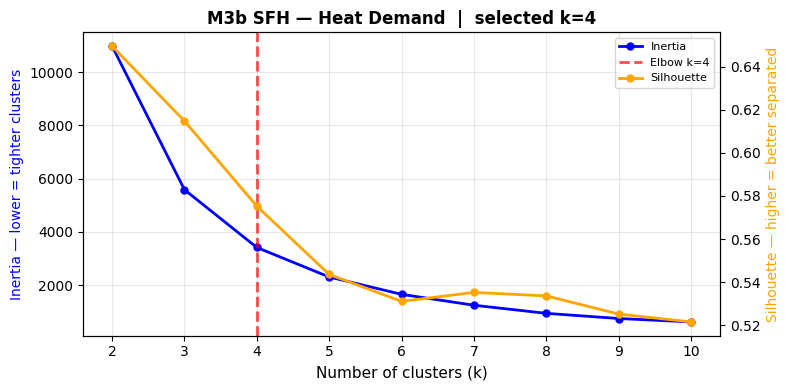

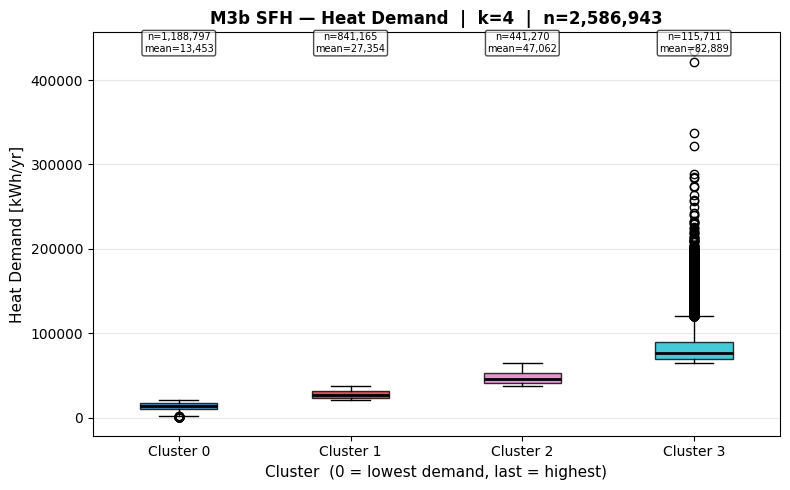

  PV Potential (20%)                  elbow k=4  silhouette preferred k=2  -> using k=4


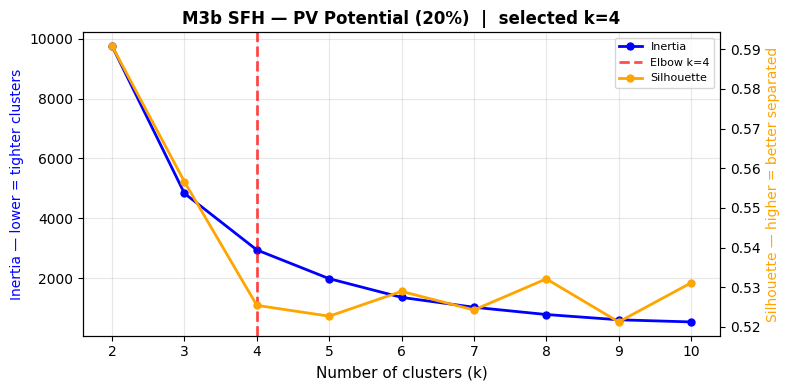

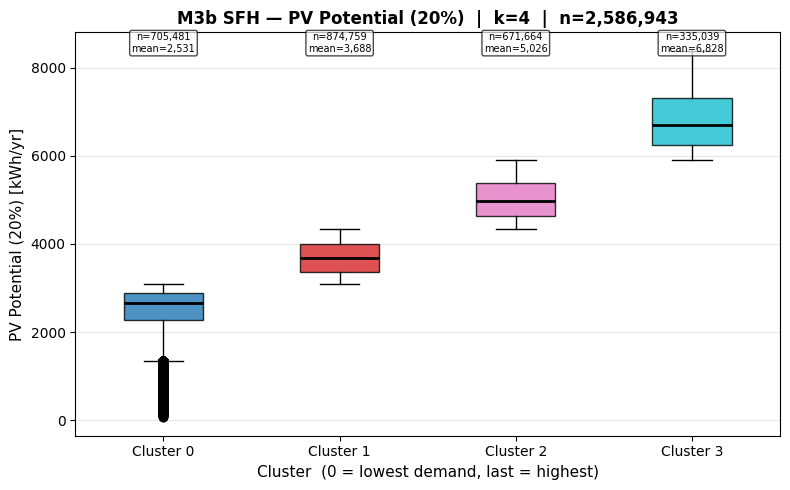


  Combinations for SFH: 18 x 4 x 4 = 288
  Saved: c:\Users\zaito\Downloads\clustering_results\method3b_by_type\SFH\M3b_SFH_assignments.csv

  TH  (482,251 buildings)
  Electricity Demand M3b              hardcoded k=11  values=[2700, 3500, 5400, 7000, 8100, 10500, 10800, 13500, 14000, 16200, 18900]
  Heat Demand                         elbow k=4  silhouette preferred k=2  -> using k=4


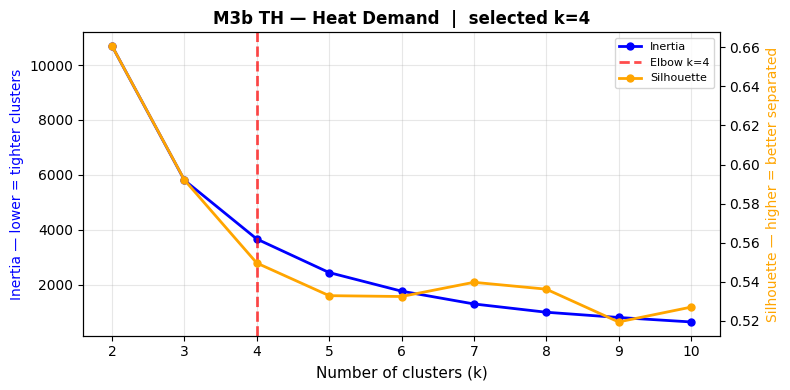

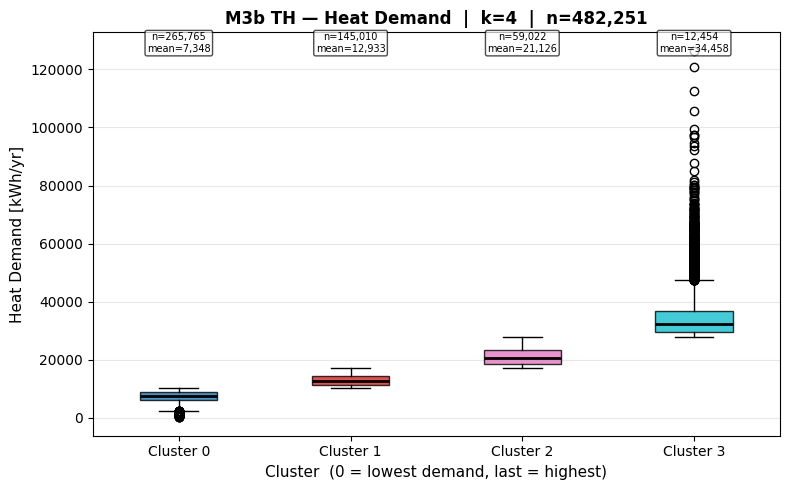

  PV Potential (20%)                  elbow k=4  silhouette preferred k=2  -> using k=4


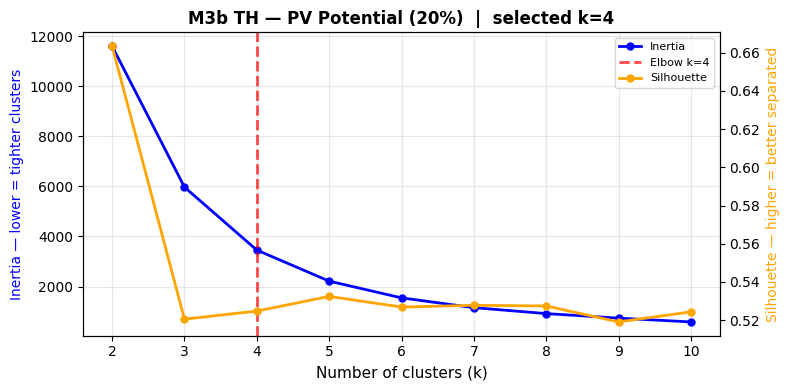

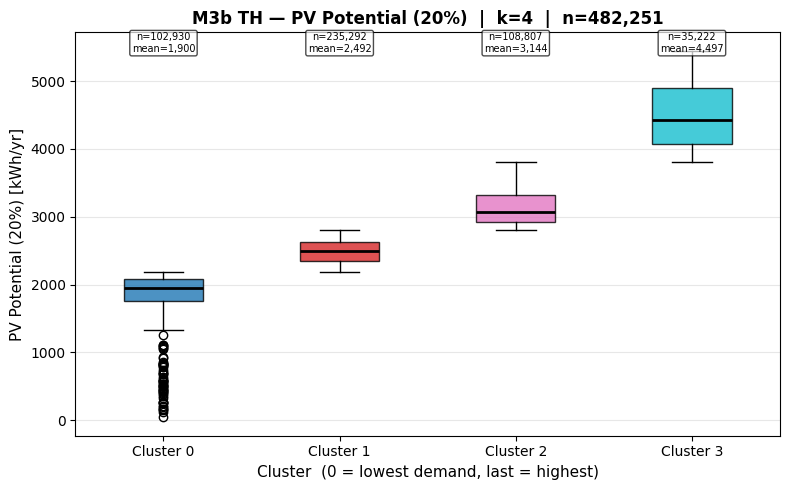


  Combinations for TH: 11 x 4 x 4 = 176
  Saved: c:\Users\zaito\Downloads\clustering_results\method3b_by_type\TH\M3b_TH_assignments.csv

  MFH  (852,384 buildings)
  Electricity Demand M3b              elbow k=4  silhouette preferred k=10  -> using k=4


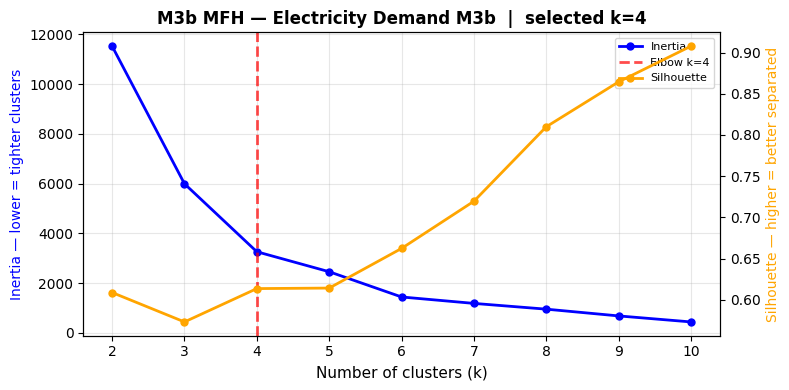

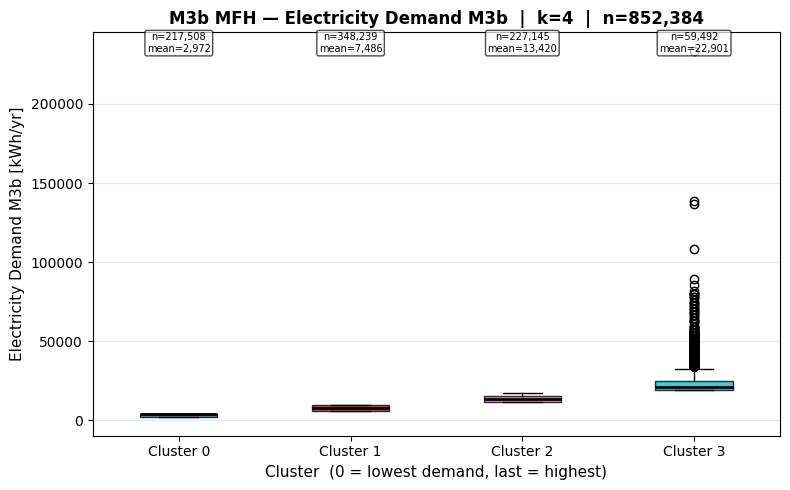

  Heat Demand                         elbow k=5  silhouette preferred k=2  -> using k=5


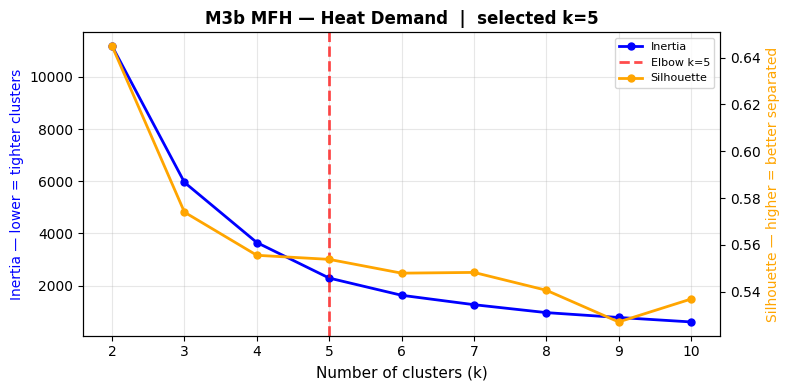

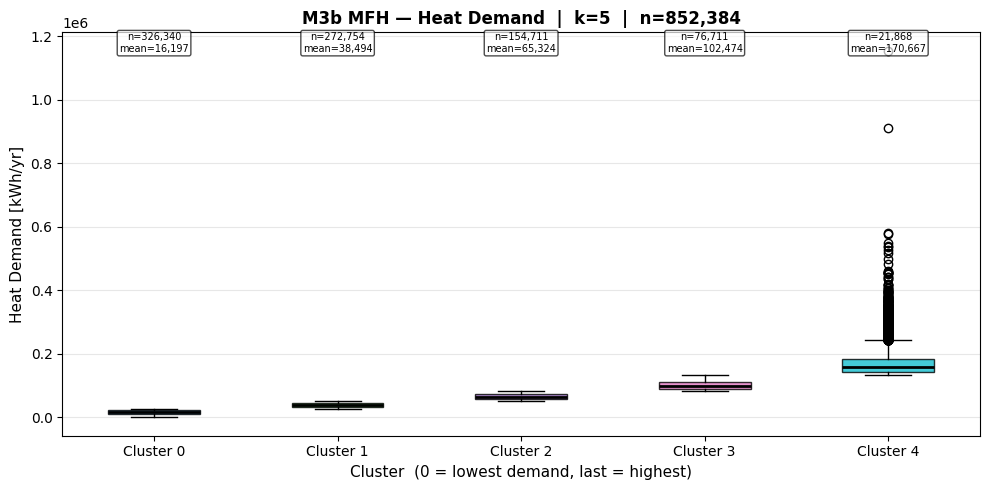

  PV Potential (20%)                  elbow k=4  silhouette preferred k=2  -> using k=4


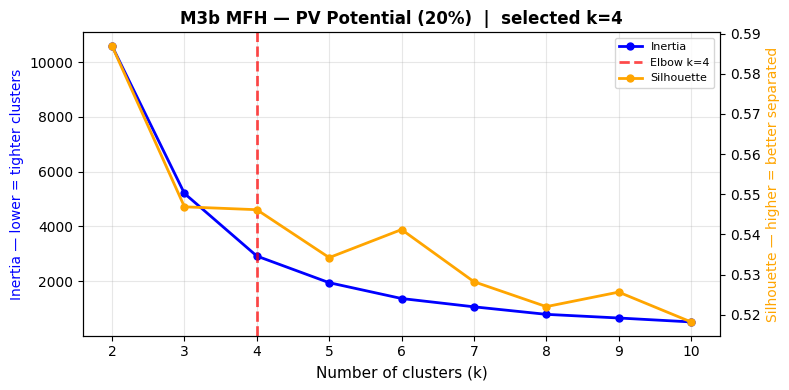

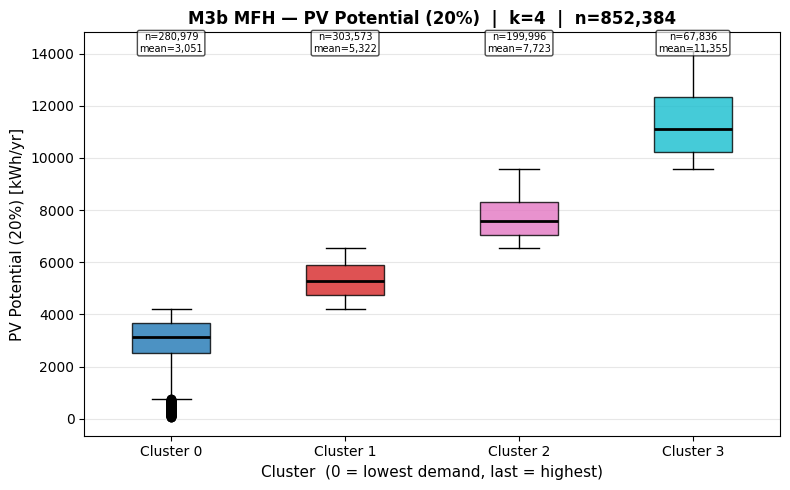


  Combinations for MFH: 4 x 5 x 4 = 80
  Saved: c:\Users\zaito\Downloads\clustering_results\method3b_by_type\MFH\M3b_MFH_assignments.csv

  AB  (5,077 buildings)
  Electricity Demand M3b              elbow k=4  silhouette preferred k=2  -> using k=4


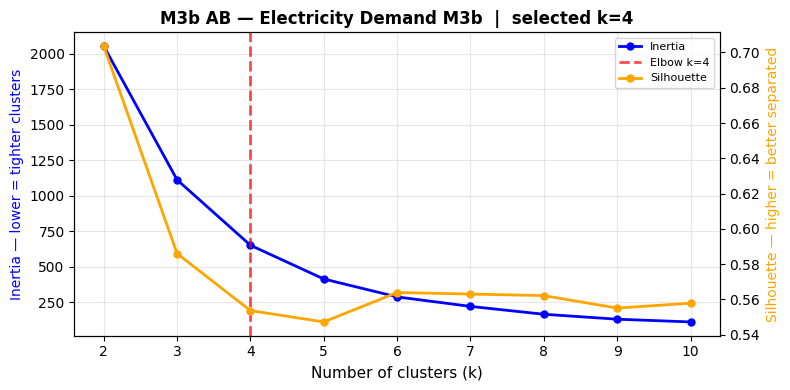

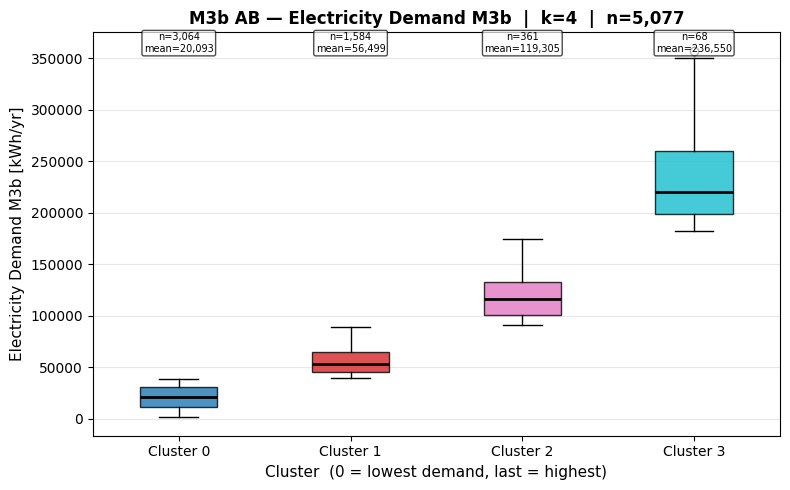

  Heat Demand                         elbow k=4  silhouette preferred k=2  -> using k=4


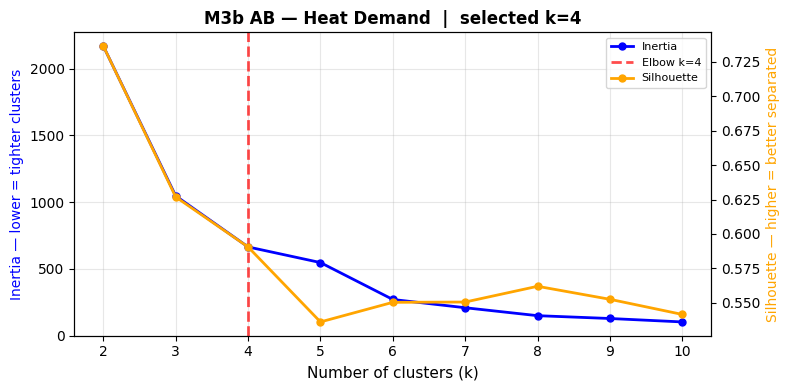

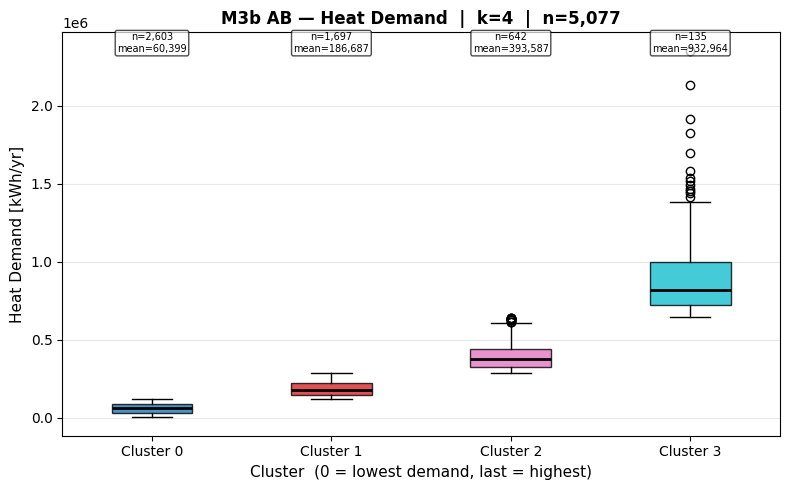

  PV Potential (20%)                  elbow k=4  silhouette preferred k=2  -> using k=4


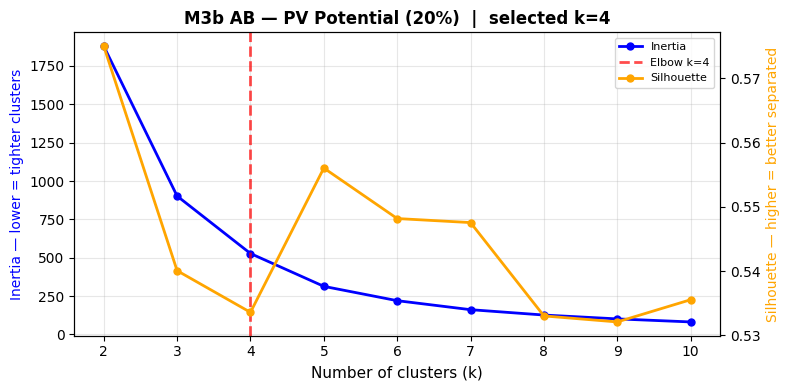

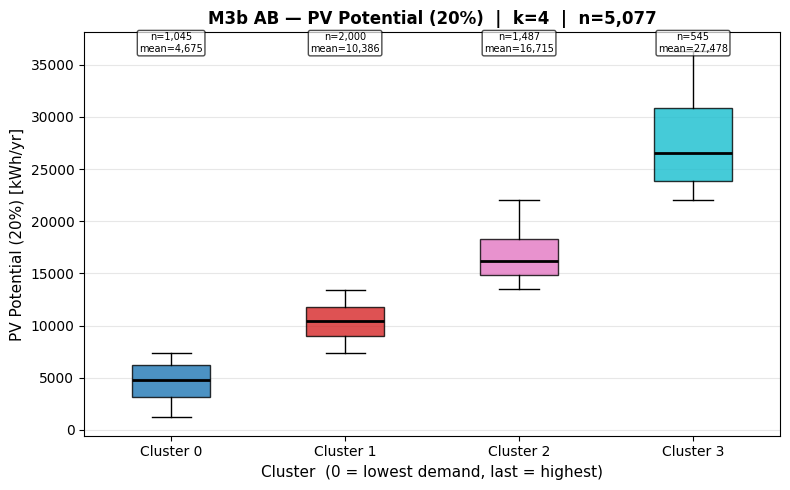


  Combinations for AB: 4 x 4 x 4 = 64
  Saved: c:\Users\zaito\Downloads\clustering_results\method3b_by_type\AB\M3b_AB_assignments.csv


In [9]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

VARIABLES = [
    ('elec_m3b_kwh',     'Electricity Demand M3b', 'kWh/yr'),
    ('heat_total_kwh',   'Heat Demand',            'kWh/yr'),
    ('pv_potential_kwh', 'PV Potential (20%)',      'kWh/yr'),
]

all_stats      = []
k_results      = {}
combo_per_type = {}

for sc in SIZE_CLASSES:
    subset = m3b[m3b['size_class'] == sc].copy().reset_index(drop=True)
    print(f'\n{"="*60}')
    print(f'  {sc}  ({len(subset):,} buildings)')
    print(f'{"="*60}')
    k_results[sc] = {}

    type_dir = os.path.join(OUTPUT_DIR, sc)
    os.makedirs(type_dir, exist_ok=True)

    for col, label, unit in VARIABLES:
        vals = subset[col].values.astype(float)

        # SFH and TH electricity — hardcode clusters from lookup table values
        # These building types always have 1 dwelling so only 2 possible values:
        # persons=2 → 2,700 kWh and persons=3 → 3,500 kWh
        # K-Means would give k=4 artificially — not meaningful with only 2 distinct values
        # Philippe: "it would be enough to just hard code the creation of these clusters
        # based on the values in the different lookup tables"
        if sc in ['SFH', 'TH'] and col == 'elec_m3b_kwh':
            unique_vals = sorted(subset[col].unique())
            val_to_cluster = {v: i for i, v in enumerate(unique_vals)}
            lbl = subset[col].map(val_to_cluster).values
            k   = len(unique_vals)
            print(f'  {label:<35} hardcoded k={k}  values={[int(v) for v in unique_vals]}')
            stats = pd.DataFrame([{
                'size_class': sc, 'variable': label, 'cluster': i,
                'n':      int((subset[col] == v).sum()),
                'min':    float(v), 'mean': float(v),
                'median': float(v), 'max':  float(v), 'std': 0.0
            } for i, v in enumerate(unique_vals)])
        else:
            lbl, stats, k = cluster_variable(vals, label, unit, sc, type_dir)

        subset[f'cluster_{col}'] = lbl
        all_stats.append(stats)
        k_results[sc][col] = k

    k_vals = [k_results[sc][col] for col, _, _ in VARIABLES]
    combo  = 1
    for k in k_vals: combo *= k
    combo_per_type[sc] = combo
    print(f'\n  Combinations for {sc}: {" x ".join(map(str, k_vals))} = {combo}')

    export_cols = ['id', 'size_class'] + \
                  [col for col, _, _ in VARIABLES] + \
                  [f'cluster_{col}' for col, _, _ in VARIABLES]
    out_path = os.path.join(type_dir, f'M3b_{sc}_assignments.csv')
    subset[export_cols].to_csv(out_path, index=False)
    print(f'  Saved: {out_path}')

## 7. Whole Dataset Clustering — Comparison Baseline

Same algorithm but all 4M buildings together — no type separation.
Shows what happens when building types are mixed.

WHOLE DATASET — comparison baseline

  Electricity Demand M3b:
  Electricity Demand M3b              elbow k=4  silhouette preferred k=10  -> using k=4


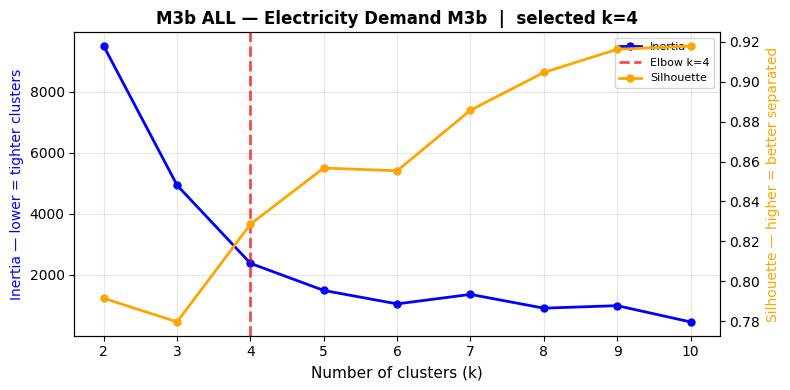

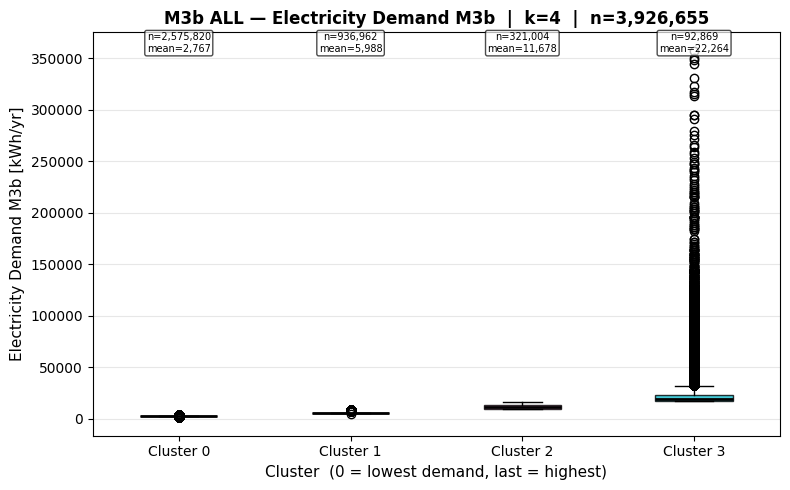


  Heat Demand:
  Heat Demand                         elbow k=4  silhouette preferred k=2  -> using k=4


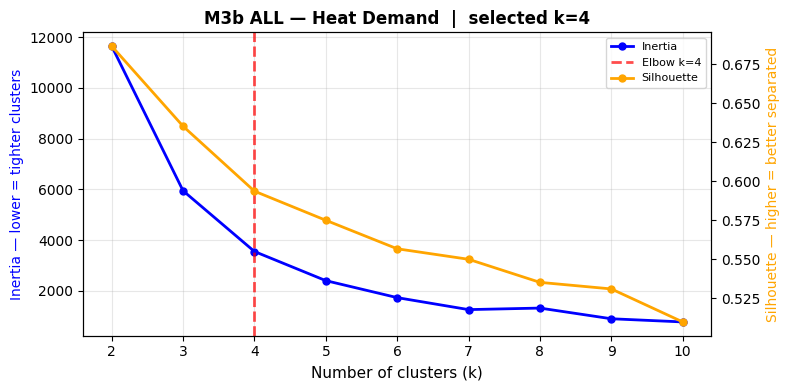

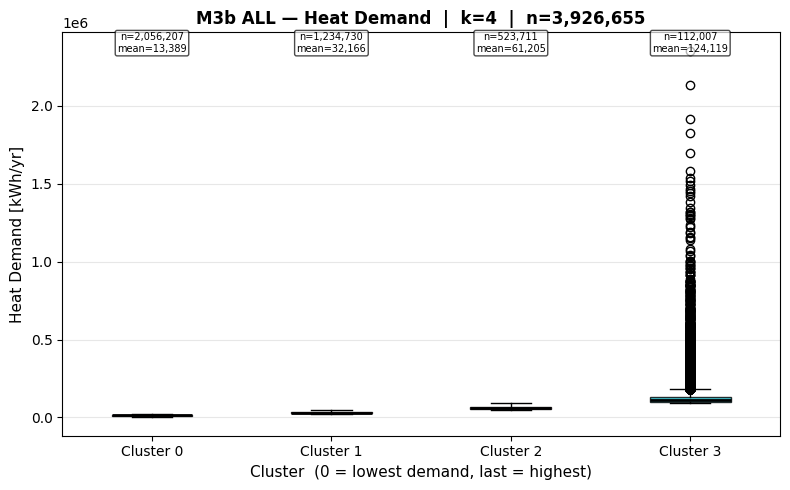


  PV Potential (20%):
  PV Potential (20%)                  elbow k=4  silhouette preferred k=2  -> using k=4


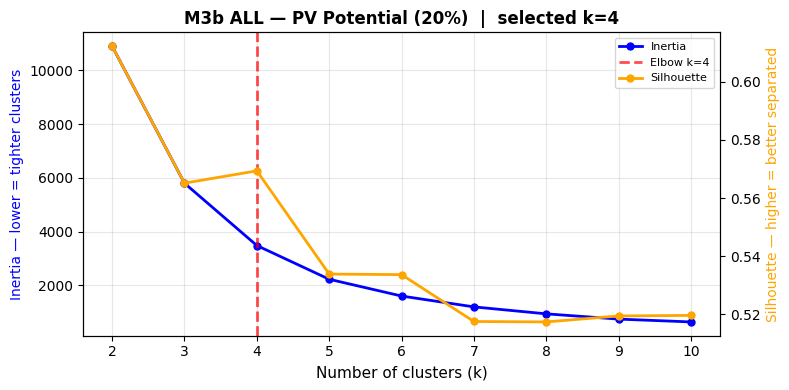

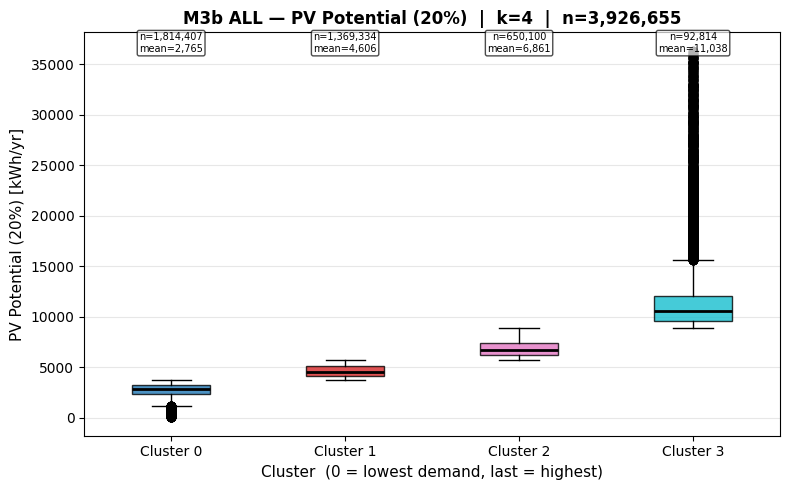


Whole dataset: 4 x 4 x 4 = 64


In [10]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

print('WHOLE DATASET — comparison baseline')
print('='*60)

whole_dir = os.path.join(OUTPUT_DIR, 'whole_dataset')
os.makedirs(whole_dir, exist_ok=True)

k_whole = {}
for col, label, unit in VARIABLES:
    vals = m3b[col].values.astype(float)
    print(f'\n  {label}:')
    lbl, stats, k = cluster_variable(vals, label, unit, 'ALL', whole_dir)
    k_whole[col] = k
    all_stats.append(stats)

combo_whole = 1
for k in k_whole.values(): combo_whole *= k
print(f'\nWhole dataset: {" x ".join(str(k_whole[c]) for c,_,_ in VARIABLES)} = {combo_whole}')

## 8. Combination Count Comparison

Key result: how many archetypes does each approach produce?

- **Whole dataset**: fewer combinations but archetypes can mix building types
- **Per type**: more combinations but each is physically realistic

In [11]:
total_per_type = sum(combo_per_type.values())

print('COMBINATION COMPARISON')
print('='*60)
print(f'\nWhole dataset approach:')
for col, label, _ in VARIABLES:
    print(f'  {label:<35}: k={k_whole[col]}')
print(f'  Total: {" x ".join(str(k_whole[c]) for c,_,_ in VARIABLES)} = {combo_whole}')

print(f'\nPer building type approach:')
for sc in SIZE_CLASSES:
    k_vals = [k_results[sc][col] for col, _, _ in VARIABLES]
    print(f'  {sc}: {" x ".join(map(str, k_vals))} = {combo_per_type[sc]}')
print(f'  Total (sum): {total_per_type}')

print(f'\nM1 vs M3b:')
print(f'  Method 1  : 292 combinations')
print(f'  Method 3b : {total_per_type} combinations')
print(f'  Difference: {292 - total_per_type} fewer in M3b')

COMBINATION COMPARISON

Whole dataset approach:
  Electricity Demand M3b             : k=4
  Heat Demand                        : k=4
  PV Potential (20%)                 : k=4
  Total: 4 x 4 x 4 = 64

Per building type approach:
  SFH: 18 x 4 x 4 = 288
  TH: 11 x 4 x 4 = 176
  MFH: 4 x 5 x 4 = 80
  AB: 4 x 4 x 4 = 64
  Total (sum): 608

M1 vs M3b:
  Method 1  : 292 combinations
  Method 3b : 608 combinations
  Difference: -316 fewer in M3b


## 9. Gap Analysis Between Adjacent Clusters

Checks whether clusters are meaningfully different from each other.
A gap below 20% means two adjacent clusters are so close they could potentially be merged.

In [12]:
stats_df = pd.concat(all_stats, ignore_index=True)

print('GAP ANALYSIS — relative difference between adjacent cluster means')
print('='*60)

for sc in SIZE_CLASSES:
    print(f'\n{sc}:')
    for col, label, _ in VARIABLES:
        sc_stats = stats_df[
            (stats_df['size_class'] == sc) &
            (stats_df['variable'] == label)
        ].sort_values('cluster')
        for i in range(len(sc_stats)-1):
            m0  = sc_stats.iloc[i]['mean']
            m1v = sc_stats.iloc[i+1]['mean']
            gap = (m1v - m0) / m0 * 100 if m0 > 0 else 0
            flag = '' if gap >= 20 else '  <- SMALL GAP'
            print(f'  {label[:20]:<22} C{i}->C{i+1}: '
                  f'{m0:>10,.0f} -> {m1v:>10,.0f} kWh  ({gap:.0f}%){flag}')

print('\nAll gaps >= 20% means clusters are well separated and meaningful.')

GAP ANALYSIS — relative difference between adjacent cluster means

SFH:
  Electricity Demand M   C0->C1:      2,700 ->      3,500 kWh  (30%)
  Electricity Demand M   C1->C2:      3,500 ->      5,400 kWh  (54%)
  Electricity Demand M   C2->C3:      5,400 ->      7,000 kWh  (30%)
  Electricity Demand M   C3->C4:      7,000 ->      8,100 kWh  (16%)  <- SMALL GAP
  Electricity Demand M   C4->C5:      8,100 ->     10,500 kWh  (30%)
  Electricity Demand M   C5->C6:     10,500 ->     10,800 kWh  (3%)  <- SMALL GAP
  Electricity Demand M   C6->C7:     10,800 ->     13,500 kWh  (25%)
  Electricity Demand M   C7->C8:     13,500 ->     14,000 kWh  (4%)  <- SMALL GAP
  Electricity Demand M   C8->C9:     14,000 ->     16,200 kWh  (16%)  <- SMALL GAP
  Electricity Demand M   C9->C10:     16,200 ->     17,500 kWh  (8%)  <- SMALL GAP
  Electricity Demand M   C10->C11:     17,500 ->     18,900 kWh  (8%)  <- SMALL GAP
  Electricity Demand M   C11->C12:     18,900 ->     21,600 kWh  (14%)  <- SMALL GAP
 

## 10. Cluster Size Validation

Checks whether any cluster is too small to be a reliable archetype.
AB is the concern — only 5,318 buildings total split into 4 clusters.

In [13]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

print('CLUSTER SIZE VALIDATION')
print('='*60)

for sc in SIZE_CLASSES:
    csv_path = os.path.join(OUTPUT_DIR, sc, f'M3b_{sc}_assignments.csv')
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    print(f'\n{sc}:')
    for col, label, _ in VARIABLES:
        clust_col = f'cluster_{col}'
        if clust_col not in df.columns:
            continue
        sizes   = df[clust_col].value_counts().sort_index()
        min_n   = sizes.min()
        min_c   = sizes.idxmin()
        warning = '  <- WARNING: very small cluster' if min_n < 100 else ''
        print(f'  {label[:20]:<22} smallest cluster: C{min_c} with {min_n:,} buildings{warning}')

CLUSTER SIZE VALIDATION

SFH:
  Electricity Demand M   smallest cluster: C17 with 1 buildings  <- WARNING: very small cluster
  Heat Demand            smallest cluster: C3 with 115,711 buildings
  PV Potential (20%)     smallest cluster: C3 with 335,039 buildings

TH:
  Electricity Demand M   smallest cluster: C8 with 2 buildings  <- WARNING: very small cluster
  Heat Demand            smallest cluster: C3 with 12,454 buildings
  PV Potential (20%)     smallest cluster: C3 with 35,222 buildings

MFH:
  Electricity Demand M   smallest cluster: C3 with 59,492 buildings
  Heat Demand            smallest cluster: C4 with 21,868 buildings
  PV Potential (20%)     smallest cluster: C3 with 67,836 buildings

AB:
  Electricity Demand M   smallest cluster: C3 with 68 buildings  <- WARNING: very small cluster
  Heat Demand            smallest cluster: C3 with 135 buildings
  PV Potential (20%)     smallest cluster: C3 with 545 buildings


## 11. Refurbishment State Cross-Tabulation

Checks whether heat clusters implicitly separate buildings by refurbishment state.

- **If high demand clusters = mostly State 1** and **low demand = mostly State 3** → clustering captures renovation level implicitly
- **If every cluster has the same mix** → clustering captures size only, not renovation

Heat demand is calculated identically in Method 1 and Method 3b — same TABULA formula.
So this result should match the Method 1 cross-tabulation.

REFURBISHMENT STATE CROSS-TABULATION

All building types combined:
Refurb State     1     2    3
Heat Cluster                 
0             15.7  76.3  8.0
1             43.5  55.1  1.3
2             79.0  20.8  0.2
3             93.6   6.4  0.0
4             97.1   2.9  0.0


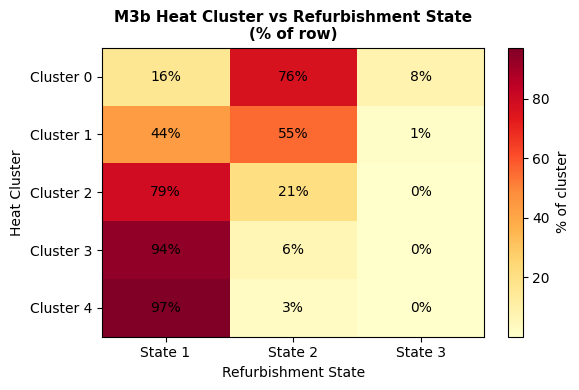


Per building type:

  SFH:
refurbishment_state        1     2    3
cluster_heat_total_kwh                 
0                       14.3  77.5  8.3
1                       44.9  54.2  0.9
2                       83.2  16.7  0.1
3                       97.4   2.6  0.0

  TH:
refurbishment_state        1     2    3
cluster_heat_total_kwh                 
0                       16.3  76.6  7.2
1                       56.7  42.7  0.5
2                       91.0   9.0  0.1
3                       97.8   2.2  0.0

  MFH:
refurbishment_state        1     2    3
cluster_heat_total_kwh                 
0                       20.2  72.1  7.7
1                       32.1  64.8  3.1
2                       62.4  37.0  0.7
3                       87.2  12.7  0.1
4                       97.1   2.9  0.0

  AB:
refurbishment_state        1     2    3
cluster_heat_total_kwh                 
0                       22.1  71.1  6.8
1                       51.0  47.2  1.8
2                       72.2  

In [14]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

print('REFURBISHMENT STATE CROSS-TABULATION')
print('='*60)

heat_col  = 'heat_total_kwh'
clust_col = f'cluster_{heat_col}'

frames = []
for sc in SIZE_CLASSES:
    csv_path = os.path.join(OUTPUT_DIR, sc, f'M3b_{sc}_assignments.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, usecols=['id', clust_col])
        df['size_class'] = sc
        frames.append(df)

if frames:
    assignments = pd.concat(frames, ignore_index=True)
    merged = m3b[['id', 'size_class', 'refurbishment_state']].merge(
        assignments, on=['id', 'size_class'], how='inner'
    )

    ct = pd.crosstab(merged[clust_col], merged['refurbishment_state'],
                     normalize='index') * 100
    ct.index.name   = 'Heat Cluster'
    ct.columns.name = 'Refurb State'
    print('\nAll building types combined:')
    print(ct.round(1).to_string())

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(ct.shape[1]))
    ax.set_xticklabels([f'State {c}' for c in ct.columns])
    ax.set_yticks(range(ct.shape[0]))
    ax.set_yticklabels([f'Cluster {i}' for i in ct.index])
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, f'{ct.values[i,j]:.0f}%',
                    ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='% of cluster')
    ax.set_title('M3b Heat Cluster vs Refurbishment State\n(% of row)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Refurbishment State')
    ax.set_ylabel('Heat Cluster')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'crosstab_heat_refurb_m3b.pdf'), bbox_inches='tight')
    plt.show()

    print('\nPer building type:')
    for sc in SIZE_CLASSES:
        sc_data = merged[merged['size_class'] == sc]
        if len(sc_data) == 0:
            continue
        ct_sc = pd.crosstab(sc_data[clust_col], sc_data['refurbishment_state'],
                            normalize='index') * 100
        print(f'\n  {sc}:')
        print(ct_sc.round(1).to_string())

## 12. Save Summary Excel

All cluster statistics and combination comparison in one file.
Location: `clustering_results/method3b_by_type/M3b_clustering_by_type_summary.xlsx`

In [15]:
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results', 'method3b_by_type')

excel_path = os.path.join(OUTPUT_DIR, 'M3b_clustering_by_type_summary.xlsx')

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:

    rows = []
    for sc in SIZE_CLASSES:
        k_vals = [k_results[sc][col] for col, _, _ in VARIABLES]
        rows.append({
            'Approach': f'Per type - {sc}',
            **{label: k_results[sc][col] for col, label, _ in VARIABLES},
            'Combinations': combo_per_type[sc]
        })
    rows.append({'Approach': 'Per type - TOTAL',
                 **{label: '' for _, label, _ in VARIABLES},
                 'Combinations': total_per_type})
    rows.append({'Approach': 'Whole dataset',
                 **{label: k_whole[col] for col, label, _ in VARIABLES},
                 'Combinations': combo_whole})
    pd.DataFrame(rows).to_excel(writer, sheet_name='Combination Comparison', index=False)

    for sc in SIZE_CLASSES:
        sc_stats = stats_df[stats_df['size_class'] == sc]
        sc_stats.to_excel(writer, sheet_name=f'Stats {sc}', index=False)

    stats_df.to_excel(writer, sheet_name='All Stats', index=False)

print(f'Saved: {excel_path}')
print('\nDone — all outputs ready.')

Saved: c:\Users\zaito\Downloads\clustering_results\method3b_by_type\M3b_clustering_by_type_summary.xlsx

Done — all outputs ready.


In [ ]:
import pandas as pd
import os

BASE_DIR = os.getcwd()
m3b = pd.read_parquet(os.path.join(BASE_DIR, 'DEA_method3b_final.parquet'),
                      columns=['size_class', 'area_m2', 'n_dwellings_m3b', 'elec_m3b_kwh'])

# Apply P95 and check SFH unique values after removal
for sc in ['SFH', 'TH']:
    mask = m3b['size_class'] == sc
    p95 = m3b.loc[mask, 'area_m2'].quantile(0.95)
    subset = m3b[mask & (m3b['area_m2'] <= p95)]
    unique_vals = sorted(subset['elec_m3b_kwh'].unique())
    print(f'{sc} after P95 (threshold={p95:.1f} m2):')
    print(f'  Unique electricity values: {unique_vals}')
    print(f'  n_dwellings unique: {sorted(subset["n_dwellings_m3b"].unique())}')
    print()

TH dwelling counts:
n_dwellings_m3b
1    507633
Name: count, dtype: int64

SFH unique electricity values (first 20):
[np.int64(2700), np.int64(3500)]


---
## Results Summary

| Size class | k Electricity | k Heat | k PV | Combinations |
|------------|:---:|:---:|:---:|:---:|
| SFH | 4 | 4 | 4 | 64 |
| TH | 3 | 5 | 5 | 75 |
| MFH | 4 | 4 | 4 | 64 |
| AB | 4 | 4 | 4 | 64 |
| **TOTAL** | | | | **267** |

**Key findings vs Method 1:**
- TH electricity k=3 vs k=4 in M1 — discrete lookup compresses the distribution
- National electricity total: 22.18 TWh (-30.6% vs BDEW 31.96 TWh)
- Method 1 remains recommended: -0.2% vs BDEW, continuous distribution, k=4 for all types
- Silhouette artificially inflates toward 1.0 for M3b electricity — artefact of discrete lookup
- Heat and PV results identical to M1 — same formula, same source